In [4]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import seaborn as sb
import matplotlib.pyplot as plt

In [7]:
%matplotlib inline

In [8]:
tips = sb.load_dataset('tips')

In [9]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


C:\Users\sidda\AppData\Local\Temp\ipykernel_19032\1586063330.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(tips['total_bill'],bins=30)


<Axes: xlabel='total_bill', ylabel='Density'>

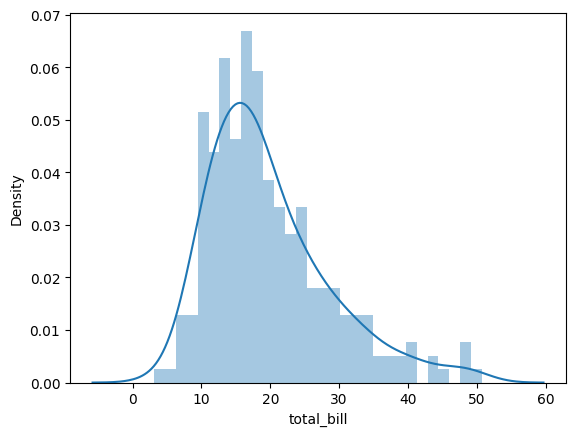

In [33]:
sb.distplot(tips['total_bill'],bins=30)

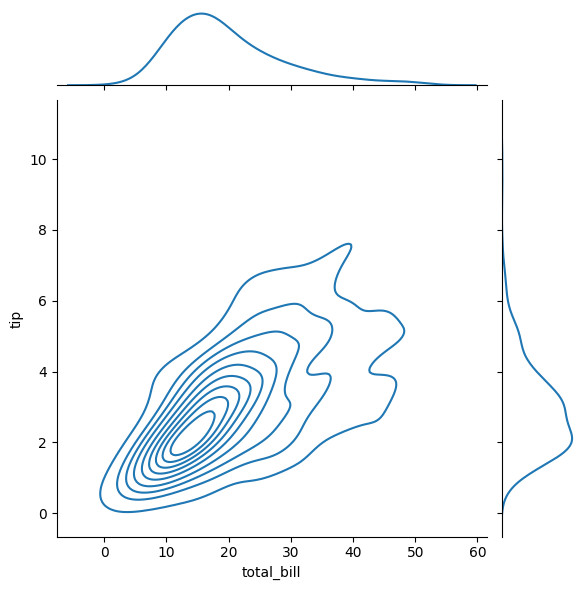

In [31]:
sb.jointplot(x='total_bill',y='tip',data=tips,kind='kde')

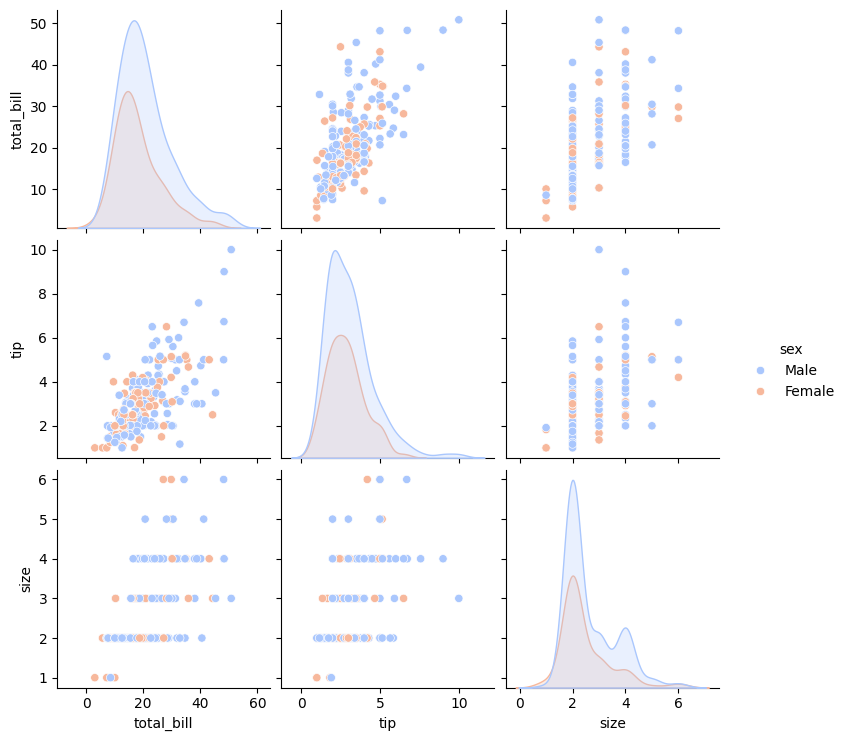

In [24]:
sb.pairplot(tips,hue='sex',palette='coolwarm')

<Axes: xlabel='total_bill'>

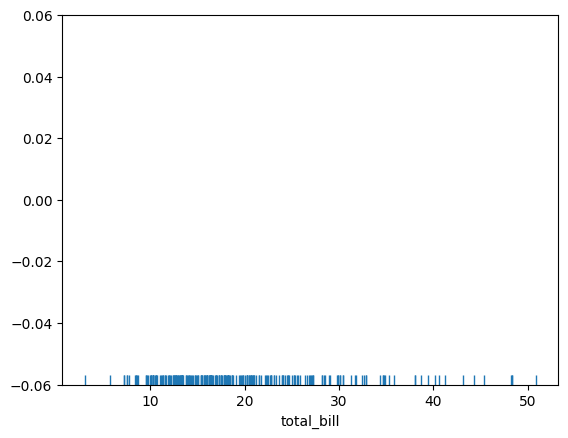

In [25]:
sb.rugplot(tips['total_bill'])

(0.0, 1.0)

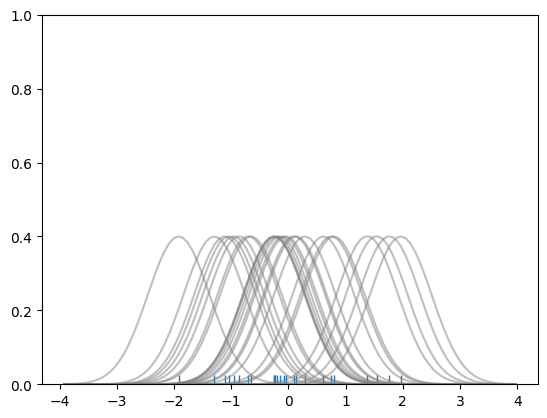

In [27]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sb.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)

Text(0.5, 0.98, 'Sum of the Basis Functions')

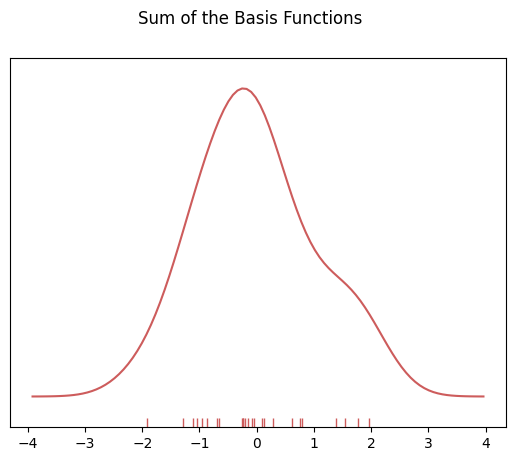

In [29]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sb.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

In [34]:

# CATEGORICAL PLOTS


<Axes: xlabel='sex', ylabel='total_bill'>

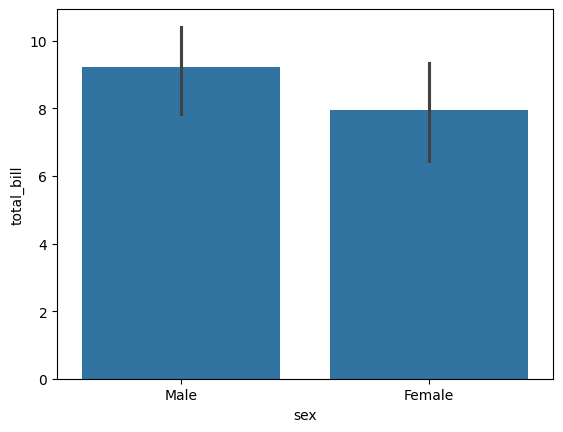

In [36]:
sb.barplot(x='sex',y='total_bill',data=tips,estimator=np.std)

<Axes: xlabel='sex', ylabel='count'>

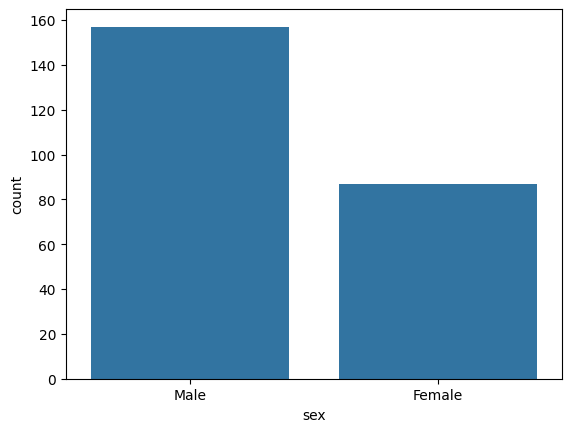

In [37]:
sb.countplot(x='sex',data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

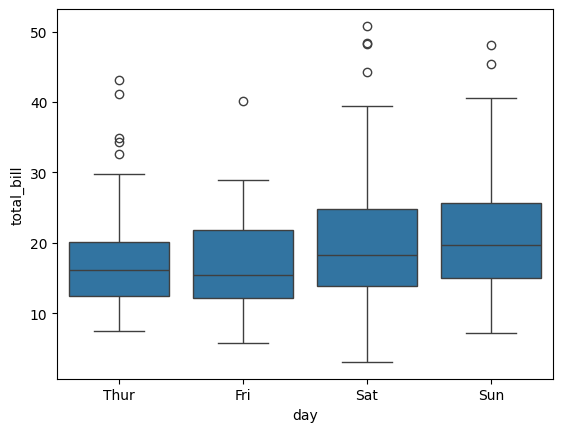

In [42]:
sb.boxplot(x='day',y='total_bill',data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

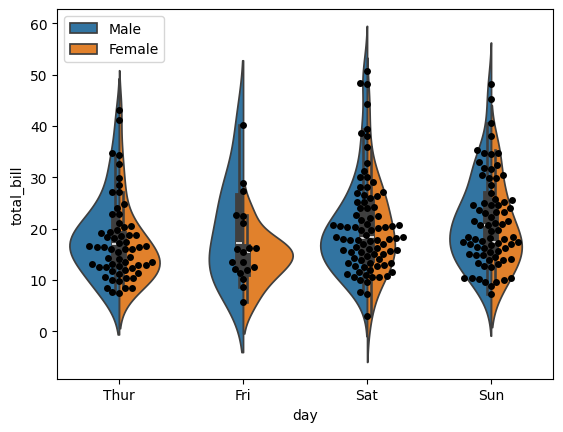

In [56]:
sb.violinplot(x='day',y='total_bill',data=tips,hue='sex',split=True)
sb.swarmplot(x='day',y='total_bill',data=tips,color='black')

<Axes: xlabel='day', ylabel='total_bill'>

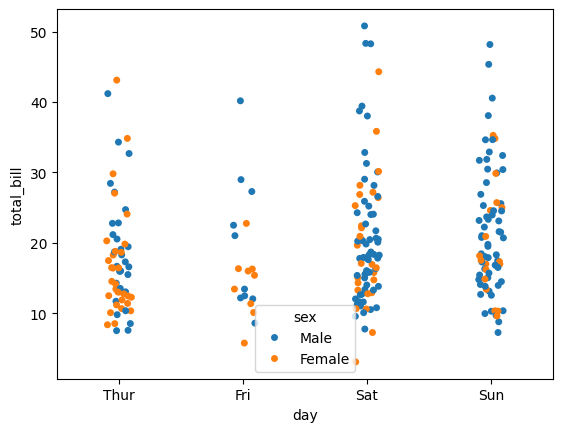

In [49]:
sb.stripplot(x='day',y='total_bill',data=tips,hue='sex')

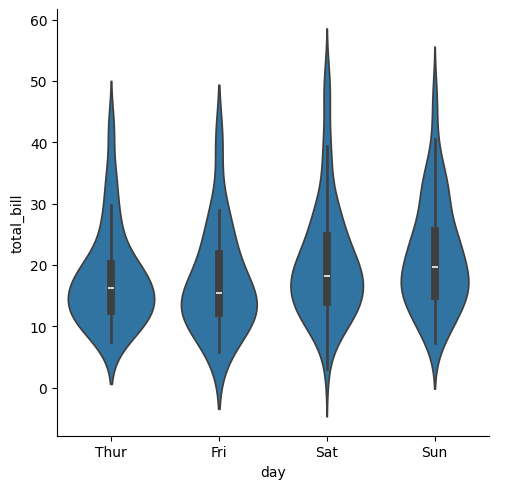

In [59]:
sb.catplot(x='day',y='total_bill',data=tips,kind='violin')

In [60]:

# MATRIX PLOTS


In [61]:
flights = sb.load_dataset('flights')

In [64]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [63]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [66]:
numeric_tips = tips.select_dtypes(include=['number'])
corr = numeric_tips.corr()

In [67]:
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

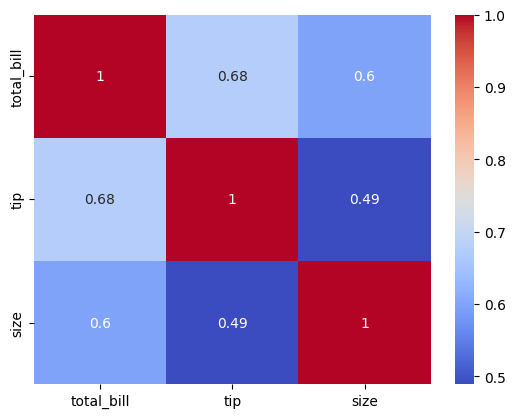

In [71]:
sb.heatmap(corr,annot=True,cmap='coolwarm')

In [75]:
fp = flights.pivot_table(index='month',columns='year',values='passengers',observed=False)

<Axes: xlabel='year', ylabel='month'>

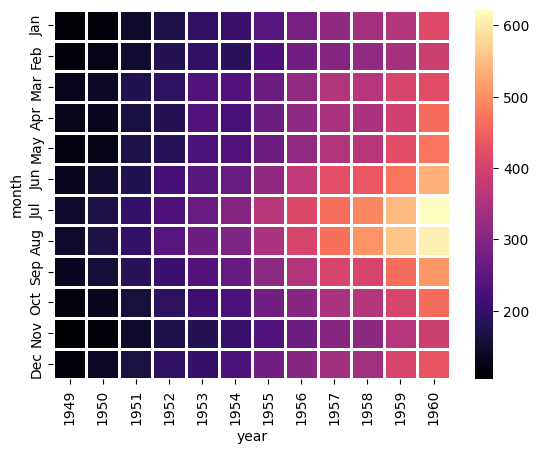

In [79]:
sb.heatmap(fp,cmap='magma',linecolor='white',linewidth=1)

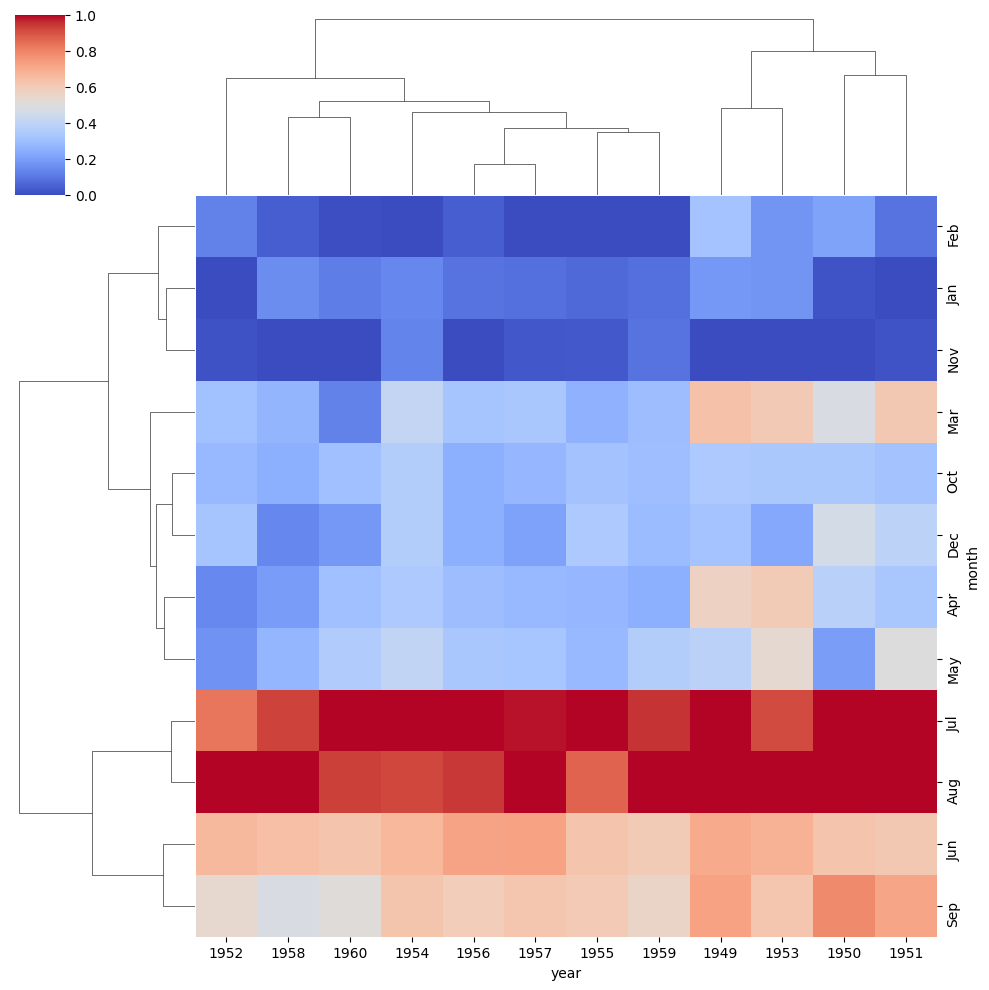

In [82]:
sb.clustermap(fp,cmap='coolwarm',standard_scale=1)

In [83]:

# GRIDS


In [85]:
iris = sb.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


C:\Users\sidda\OneDrive\Desktop\Data_Science\mynewv\Lib\site-packages\seaborn\axisgrid.py:1550: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(x=data_k, label=label_k, color=color, **plot_kwargs)
C:\Users\sidda\OneDrive\Desktop\Data_Science\mynewv\Lib\site-packages\seaborn\axisgrid.py:1550: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457

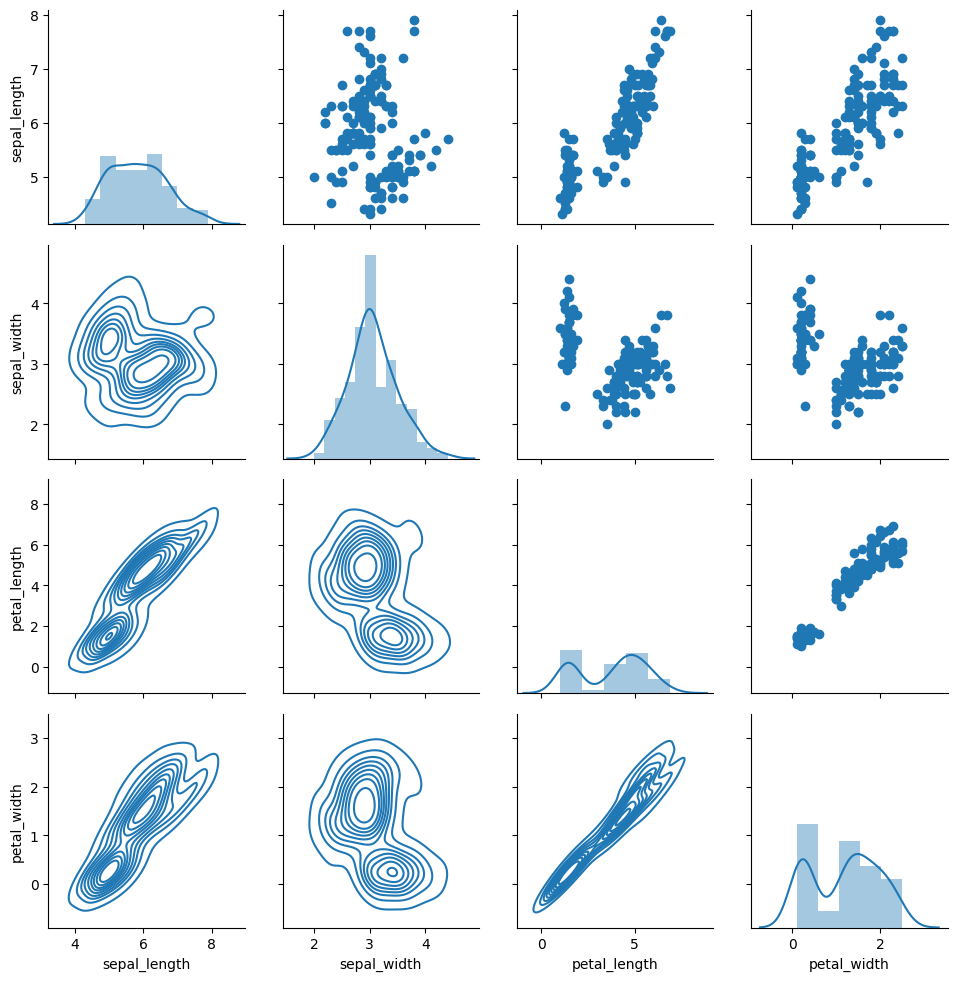

In [91]:
g = sb.PairGrid(iris)
g.map_diag(sb.distplot)
g.map_upper(plt.scatter)
g.map_lower(sb.kdeplot)

C:\Users\sidda\OneDrive\Desktop\Data_Science\mynewv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
C:\Users\sidda\OneDrive\Desktop\Data_Science\mynewv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*pl

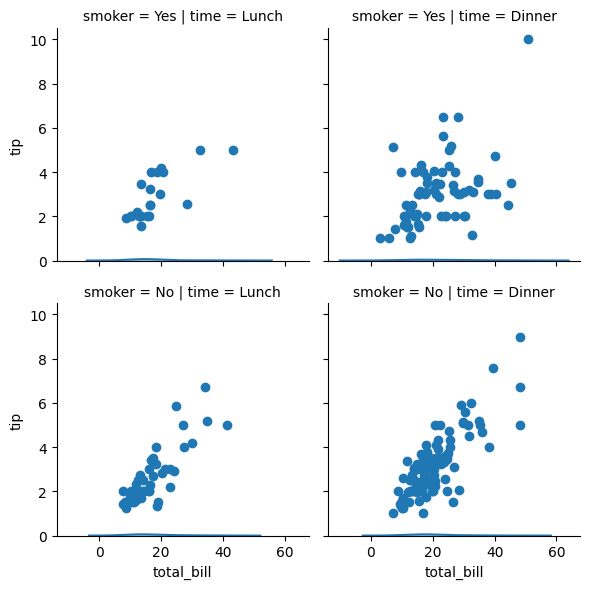

In [96]:
grid = sb.FacetGrid(data=tips,col='time',row='smoker')
grid.map(sb.distplot,'total_bill')
grid.map(plt.scatter,'total_bill','tip')

In [97]:

# REGRESSION PLOTS


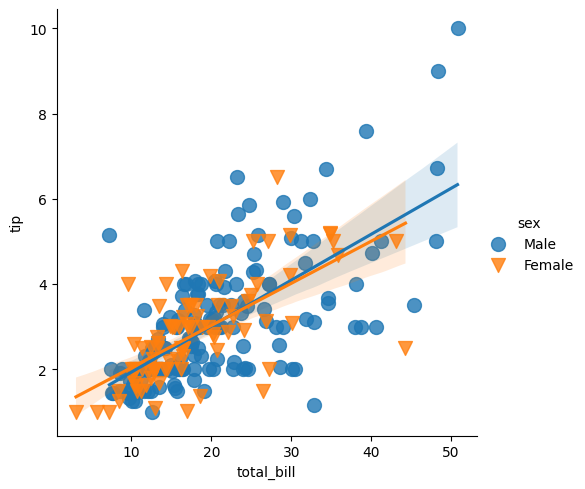

In [102]:
sb.lmplot(x='total_bill',y='tip',data=tips,hue='sex',markers=['o','v'],scatter_kws={'s':100})

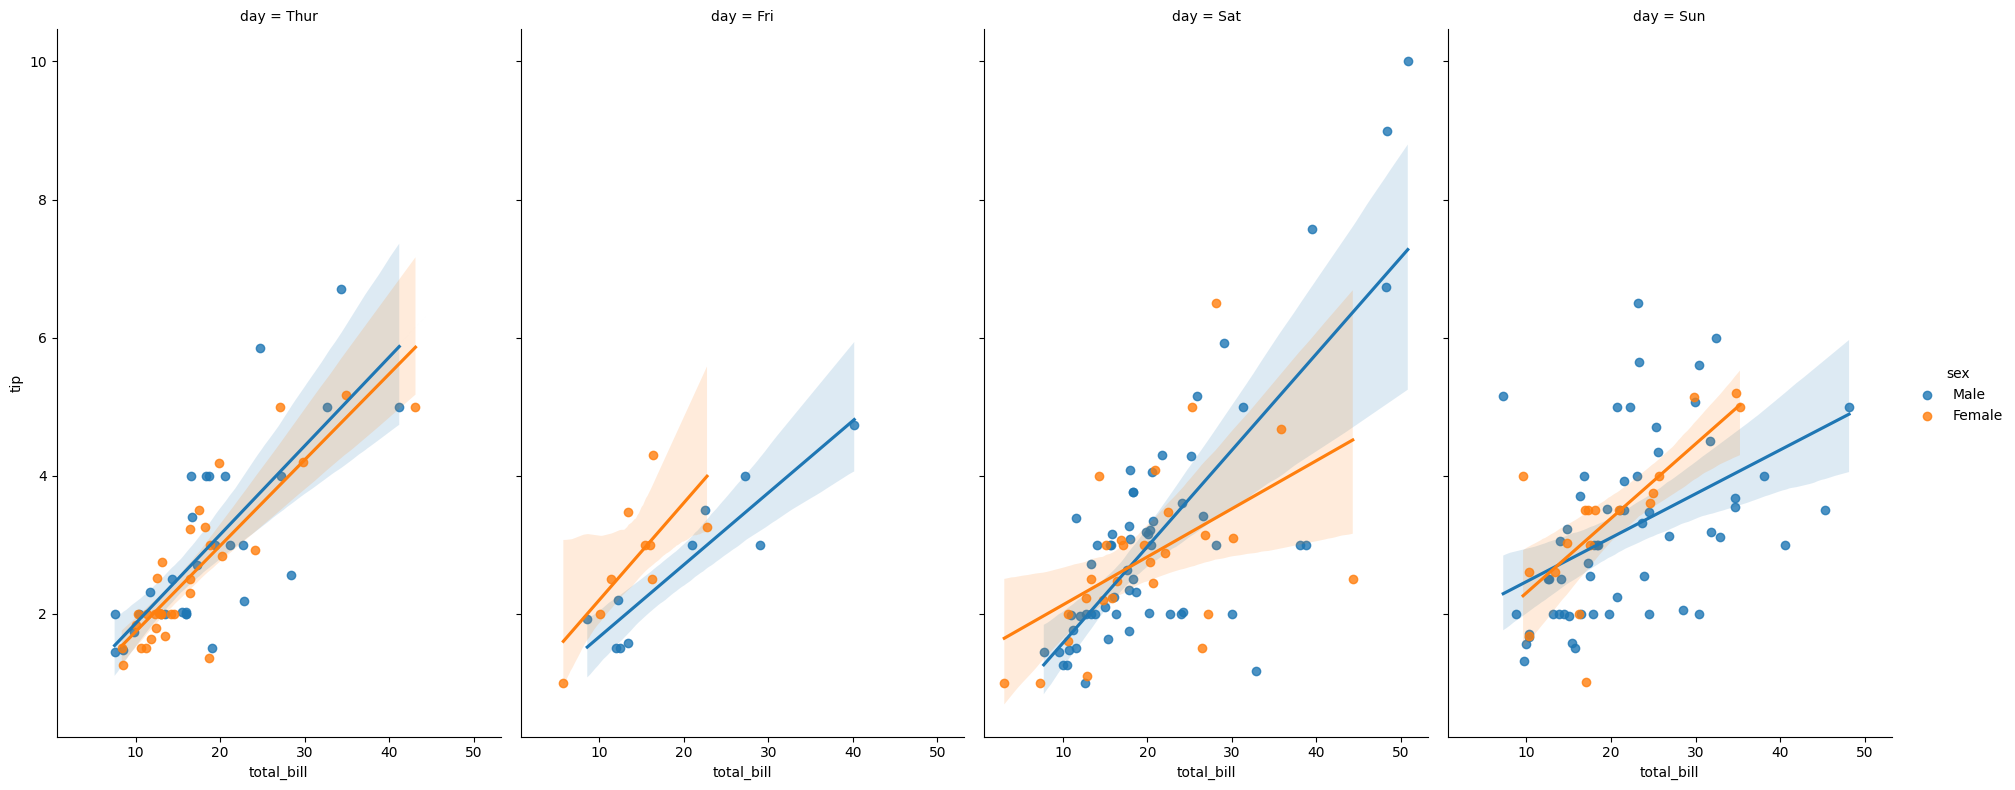

In [106]:
sb.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',aspect=0.6,height=8)

<Axes: xlabel='sex', ylabel='count'>

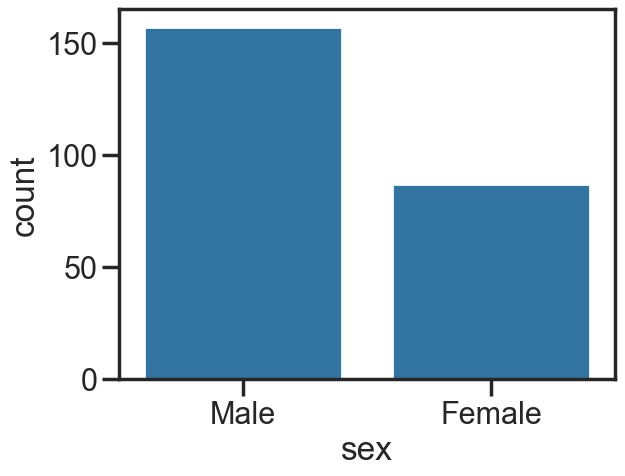

In [122]:
# plt.figure(figsize=(12,3))

#we can use font_scale to set the size of the font if we're unsatisifed
#we default the context is notebook
# sb.set_context('poster')

sb.set_style('ticks')

sb.countplot(x='sex',data=tips)
# sb.despine(left=True,bottom=True)

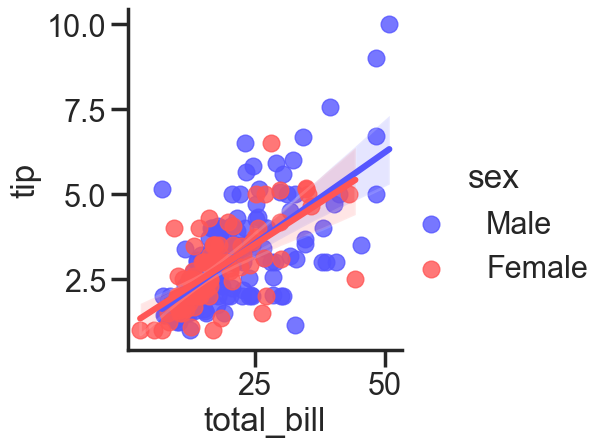

In [124]:
sb.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='seismic')